## Inportamos la base de datos y visualizamos los datos

In [8]:
import pandas as pd
df = pd.read_excel("diabetes.xlsx")
df.head(15)

,Embarazos,Glucosa,Presión Arterial,Grosor de Piel,Insulina,IMC,Función de Pedigrí de Diabetes,Edad,"Diabetes: 1 = Sí, 0 = No"
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


### Listamos las variables que usaremos y que tenemos que hacer una limpieza

In [ ]:
# Columnas donde el valor 0 no tiene sentido médico
columnas_a_limpiar = ["Glucosa", "Presión Arterial", "Grosor de Piel", "Insulina", "IMC"]
columnas_a_limpiar

['Glucosa', 'Presión Arterial', 'Grosor de Piel', 'Insulina', 'IMC']

### Importamos la libreria numpy y remplazamos los ceros por NAN

In [10]:
# Reemplazar los ceros por NaN en esas columnas
import numpy as np
df[columnas_a_limpiar] = df[columnas_a_limpiar].replace(0, np.nan)

### Visualizamos los valores faltantes  


In [11]:
# Ver cuántos valores faltantes hay por columna
print("Valores faltantes por columna:")
print(df[columnas_a_limpiar].isnull().sum())

Valores faltantes por columna:
Glucosa               5
Presión Arterial     35
Grosor de Piel      227
Insulina            374
IMC                  11
dtype: int64


### A los valores faltantes los reemplazaremos por la media de cada columna

In [12]:
# Rellenar los valores faltantes con la mediana de cada columna
for col in columnas_a_limpiar:
    df[col] = df[col].fillna(df[col].median())

### Visualizamos nuevamente los valores nulos

In [13]:
# Verificar que ya no hay valores nulos
print("\nValores faltantes después de la limpieza:")
print(df[columnas_a_limpiar].isnull().sum())


Valores faltantes después de la limpieza:
Glucosa             0
Presión Arterial    0
Grosor de Piel      0
Insulina            0
IMC                 0
dtype: int64


### Visualizamos nuevamente nuestra base de datos 

In [15]:
df.head(15)

,Embarazos,Glucosa,Presión Arterial,Grosor de Piel,Insulina,IMC,Función de Pedigrí de Diabetes,Edad,"Diabetes: 1 = Sí, 0 = No"
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
5,5,116.0,74.0,29.0,125.0,25.6,0.201,30,0
6,3,78.0,50.0,32.0,88.0,31.0,0.248,26,1
7,10,115.0,72.0,29.0,125.0,35.3,0.134,29,0
8,2,197.0,70.0,45.0,543.0,30.5,0.158,53,1
9,8,125.0,96.0,29.0,125.0,32.3,0.232,54,1


### Calculamos la correlacion de vada variable 

In [ ]:
correlaciones = df.corr(numeric_only=True)["Diabetes: 1 = Sí, 0 = No"].sort_values(ascending=False)

In [17]:
print(correlaciones)

Diabetes: 1 = Sí, 0 = No          1.000000
Glucosa                           0.492782
IMC                               0.312038
Edad                              0.238356
Embarazos                         0.221898
Grosor de Piel                    0.214873
Insulina                          0.203790
Función de Pedigrí de Diabetes    0.173844
Presión Arterial                  0.165723
Name: Diabetes: 1 = Sí, 0 = No, dtype: float64


### Visualizamos las variables que influyen mas en la diabetes

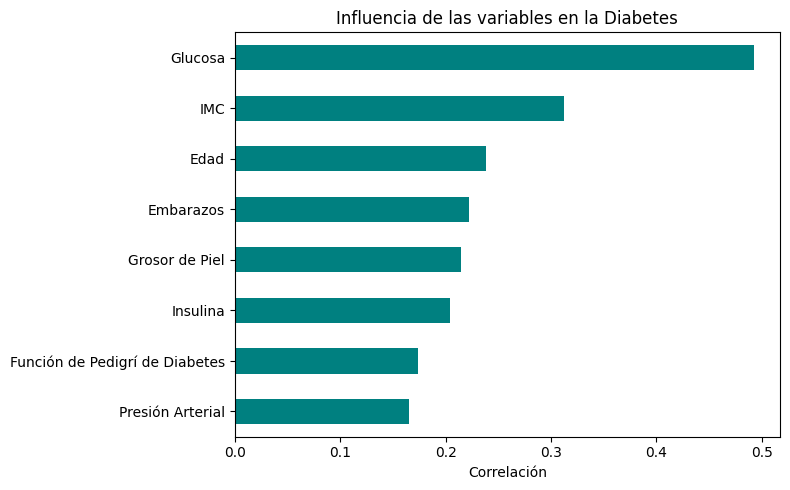

In [18]:
import matplotlib.pyplot as plt

correlaciones.drop("Diabetes: 1 = Sí, 0 = No").plot(kind="barh", figsize=(8,5), color="teal")
plt.title("Influencia de las variables en la Diabetes")
plt.xlabel("Correlación")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()